In [1]:
####################################
#ENVIRONMENT SETUP

In [2]:
#LIBRARIES

#system
import os
os.environ["HDF5_USE_FILE_LOCKING"] = "FALSE"
import sys

#math and array operations
import numpy as np
import pandas as pd
import math

#plotting
import matplotlib
# matplotlib.use("Agg") #UNCOMMENT IF PLOTTING WITHIN JUPYTER DOCUMENT
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import TwoSlopeNorm
from matplotlib.colors import ListedColormap, BoundaryNorm

import cartopy.crs as ccrs
import cartopy.feature as cfeature

#data classes
import xarray as xr
import h5py
import pickle 

#loading bar
from tqdm import tqdm

#dates
from datetime import datetime, timedelta

In [3]:
#Importing DirectoryManager Class
sys.path.append(os.path.join("/glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/","DataAnalysis"))
from CLASSES_Directories import DirectoryManager_Class

In [4]:
DirectoryManager = DirectoryManager_Class()

codeType = os.path.join("DataAnalysis", "Observation_Data")
dataType = "RainfallTimeseries"

outputDirectory = DirectoryManager.GetOutputDirectory(codeType, dataType)
outputPlottingDirectory = DirectoryManager.GetOutputPlottingDirectory(codeType, dataType)

 DirectoryManager_Class Summary
 Main Directory:           /glade/u/home/aroseman/Projects/Regional-MPAS-Project
 Main Scratch Directory:   /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project
 Scratch Directory:        /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0
 Data Directory:           /glade/work/aroseman/Projects/Regional-MPAS-Project/Code/DATA
 Main Output Directory:    /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT
 Main Output Plotting Directory:    /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/PLOTTING
 Main Code Directory:      /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles
 Current Code Directory:   /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/CodeFiles/DataAnalysis/Observation_Data/PRECIP/RainfallHistogram



In [5]:
#Importing ModelData Class
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis","MPAS_Model_Data"))
from CLASSES_ModelData import StructuredModelData_Class, DataOperator_Class

In [6]:
#Importing ModelData Class
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis","MPAS_Model_Data"))
from CLASSES_PlottingModelData import FigurePlotting_Class

In [160]:
#Setup

Region = "PRECIP"; Case = "WET"; spinup_hours = "12"
Region = "PRECIP"; Case = "DIURNAL"; spinup_hours = "12"

In [161]:
#Load Model Directory Class
RunType = (Region,Case,"NSSL",spinup_hours)
ModelData_NSSL = StructuredModelData_Class(DirectoryManager.mainDirectory, DirectoryManager.scratchDirectory, RunType)

RunType = (Region,Case,"TEMPO",spinup_hours)
ModelData_TEMPO = StructuredModelData_Class(DirectoryManager.mainDirectory, DirectoryManager.scratchDirectory, RunType)

Found 241/289 files matching expected times.
Opened history file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/PRECIP/DIURNAL/MPAS-Model_NSSL/model_run_spinup12hrs/history_cartesian/history.2022-07-15_12.00.00.latlon.nc
Opened diag file: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/PRECIP/DIURNAL/MPAS-Model_NSSL/model_run_spinup12hrs/diag_cartesian/diag.2022-07-15_12.00.00.latlon.nc

=== MPAS Structured (lat-lon) Model Data Summary ===
 Region:         PRECIP
 Case:           DIURNAL
 Microphysics:   NSSL
 Resolution:     20-1km
 Time Step:      15mins
 Time Range:     2022-07-15 to 2022-07-18
 Coordinates:    ['latitude', 'longitude', 'nVertLevels', 'nVertLevelsP1']
 # History Files:241
 # Diag Files:   241
 # Time Steps:   241
 Data Directory: /glade/derecho/scratch/aroseman/Projects/Regional-MPAS-Project/MPAS_Atmosphere_8.3.0/PRECIP/DIURNAL/MPAS-Model_NSSL/model_run_spinup12hrs
 Static File:    PRECIP_re

In [162]:
#Importing ModelData Class
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis"))
from CLASSES_DataSubsetting import DataSubsetting_Class

In [163]:
#Importing Radar Classes
sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis","Observation_Data"))
from CLASSES_RadarDataLoading import RadarData_MRMS_Class, RadarObservationMask_Class

sys.path.append(os.path.join(DirectoryManager.mainCodeDirectory,"DataAnalysis"))
from CLASSES_RadarDataPlotting import RadarPlotting_Class

In [164]:
#IMPORT FUNCTIONS
# --- Add your Functions folder to sys.path ---
import sys
path = os.path.join(DirectoryManager.mainCodeDirectory, 'Functions_2.0')
sys.path.append(path)


# --- Import all your function modules ---
import importlib
modules = [
    "AreaAverageFunctions",
    "ComputationFunctions",
    "DataFunctions",
    "DerivativeFunctions",
    "PlottingFunctions",
    "StatisticalFunctions",
]
for mod in modules:
    globals()[mod] = importlib.import_module(mod)        # import module itself
    globals().update(vars(globals()[mod]))              # import all functions into global namespace

In [165]:
####################################
#GETTING PRECIP DATA

In [166]:
# #Loading Radar Mask #decided not to use here
# RadarDataMask = RadarObservationMask_Class.LoadMaskData(DirectoryManager, ModelData_NSSL) 

In [167]:
def SubsetData_Time(data,yearmonthday):
    data_T = data.sel(time=yearmonthday)
    # print(data_T.time) #testing
    return data_T

In [168]:
def GetMean(variableSubset):
    #(1/A) times integral of phi dA 
    #dA is [(R*cos(Lat)dLon)][RdLat] = R^2 cos(Lat)dLatdLon ==> weight is simply cos(Lat)
    weights = np.cos(np.deg2rad(variableSubset.latitude))
    variableMean = variableSubset.weighted(weights).mean(
        dim=("latitude", "longitude"),
        skipna=True
    )
    return variableMean

In [169]:
# #TESTING LOADING AND PLOTTING

# #LOADING DATA
# import struct
# filePath = "CB_GC_PCP_1H_RAD.20220606.0400"
# Ny = 441; Nx = 561
# f=open(filePath,'rb')
# header=f.read(170) # header
# rain=np.reshape(struct.unpack('@'+str(Ny*Nx)+'h',f.read(Ny*Nx*2)),[Ny,Nx],'F')
# rain = rain / 4 #converting from units of 0.25 mm to mm
# rain[rain<0] = np.nan
# rain = rain.T
# rain = rain[::-1]

# #GETTING COORDINATES
# def BuildQPELonLat(nx, ny):
#     dx = 12.5 / 1000.0
#     lon0 = 118.0
#     lat0 = 27.0

#     lon = lon0 + dx * np.arange(nx)
#     lat = lat0 - dx * np.arange(ny)

#     qpeLon, qpeLat = np.meshgrid(lon, lat)
#     return qpeLon, qpeLat
# ny, nx = rain.shape
# qpeLon, qpeLat = BuildQPELonLat(nx, ny)

# #####################################

# fig = plt.figure(figsize=(10, 8))

# ax = plt.axes(projection=ccrs.PlateCarree())

# cf = ax.contourf(
#     qpeLon,
#     qpeLat,
#     rain,
#     levels=20,
#     transform=ccrs.PlateCarree(),
#     cmap="turbo"
# )

# # --- Map features ---
# ax.coastlines(resolution="10m", linewidth=1.2)
# ax.add_feature(cfeature.BORDERS, linewidth=1.0)
# ax.add_feature(cfeature.LAND, facecolor="none", edgecolor="black", linewidth=0.5)
# ax.add_feature(cfeature.OCEAN, facecolor="none")

# # Optional: Taiwan outline looks better with this
# ax.add_feature(cfeature.STATES, linewidth=0.5)

# # --- Domain bounds (important!) ---
# ax.set_extent(
#     [qpeLon.min(), qpeLon.max(), qpeLat.min(), qpeLat.max()],
#     crs=ccrs.PlateCarree()
# )
# gl = ax.gridlines(
#     crs=ccrs.PlateCarree(),
#     draw_labels=True,
#     linewidth=0.8,
#     color="gray",
#     alpha=0.6,
#     linestyle="--"
# )
# gl.top_labels = False
# gl.right_labels = False

# plt.colorbar(cf, ax=ax, label="Rainfall (mm)")
# fig.suptitle("Accumulated rainfall at 20220606.0400")

In [170]:
def GetAccumulatedPrecipData_Model(ModelData): 
    #getting yearmonthdayhour list
    dt_list = [datetime.strptime(t, "%Y-%m-%d_%H.%M.%S") for t in ModelData.timeStrings]
    start = dt_list[0]
    target = start #+ timedelta(hours=13) #only using for rainfall histogram
    # print(f"start_time: {target}")
    
    # Find the entry closest to +12 hours
    closest = min(dt_list, key=lambda x: abs(x - target))
    
    closest_idx = dt_list.index(closest)
    times = ModelData.timeStrings[closest_idx:]

    precipData_model_T_Subset_Mean = []; timeList = []
    for t in tqdm(times):
        data = ModelData.GetDataTimestep(t,printout=False)
        precipData_model_T = data['rainnc']+data['rainc']
    

        # --- subset the region ---
        precipData_model_T_Subset = DataSubsetting_Class.SubsetDataRegion(
            precipData_model_T, ModelData
        )

        # precipData_model_T_Subset=precipData_model_T_Subset.where(RadarDataMask == True) #decided not to use here
        
        # --- mean of the subset domain ---
        meanValue = GetMean(precipData_model_T_Subset).item()
        precipData_model_T_Subset_Mean.append(meanValue)
        timeList.append(t)

    timeList = [datetime.strptime(t, "%Y-%m-%d_%H.%M.%S") for t in timeList]
    return np.array(precipData_model_T_Subset_Mean),np.array(timeList)

import os
import xarray as xr
import numpy as np
from datetime import datetime

def LoadOrRun_GetAccumulatedPrecipData_Model(
    ModelData,
    overwrite=False
):
    """
    Load or compute model domain-mean accumulated precipitation time series.
    """

    os.makedirs(outputDirectory, exist_ok=True)

    fileName = (
        f"{ModelData.region}_"
        f"{ModelData.case}_"
        f"{ModelData.spinup_hours}hrs_"
        f"{ModelData.mpType}_"
        f"Model_Precipitation_Timeseries.nc"
    )
    filePath = os.path.join(outputDirectory, fileName)

    # --------------------------------------------------
    # Load
    # --------------------------------------------------
    if os.path.exists(filePath) and not overwrite:
        print(f"Loading model precip time series from disk:")
        print(f"  {filePath}")
        with xr.open_dataset(filePath) as ds:
            precipMean = ds["precip_mean"].values
            time_np = ds["time"].values

        # FIX: convert numpy.datetime64 → datetime.datetime
        timeArray = np.array(
            [t.astype("datetime64[ms]").astype(datetime) for t in time_np],
            dtype=object
        )

        return precipMean, timeArray

    # --------------------------------------------------
    # Run
    # --------------------------------------------------
    print("Computing model accumulated precip time series")
    precipMean, timeArray = GetAccumulatedPrecipData_Model(ModelData)

    # --------------------------------------------------
    # Save
    # --------------------------------------------------
    ds = xr.Dataset(
        data_vars={
            "precip_mean": ("time", precipMean),
        },
        coords={
            "time": np.array(timeArray, dtype="datetime64[ms]"),
        }
    )

    ds["precip_mean"].attrs["description"] = "Domain-mean accumulated precipitation"
    ds.attrs["region"] = ModelData.region
    ds.attrs["case"] = ModelData.case
    ds.attrs["spinup_hours"] = ModelData.spinup_hours
    ds.attrs["microphysics"] = ModelData.mpType

    ds.to_netcdf(filePath)
    print(f"Saved model precip time series to disk:")
    print(f"  {filePath}")

    return precipMean, timeArray

In [171]:
#DATA LOADING FOR PRECIP QPE DATA

def CorrectSimulationDates(ModelData, simulationDates):
    if int(ModelData.spinup_hours) <= 0:
        # Convert first date to Timestamp
        first_date = pd.to_datetime(simulationDates[0])
        # Subtract one day
        prev_date = (first_date - pd.Timedelta(days=1)).strftime('%Y-%m-%d')
        # Prepend
        simulationDates = [prev_date] + simulationDates
    return simulationDates

def GetPRECIP_QPE_DataDirectory(ModelData):
    simulationDates = ModelData.simulationDates
    simulationDates2 = CorrectSimulationDates(ModelData, simulationDates)

    inputDirectory = os.path.join(DirectoryManager.dataDirectory,
             f"Observation_Data/PRECIP/QPE1HR", ModelData.case)
    return inputDirectory

import struct

def BuildQPELonLat(nx, ny):
    dx = 12.5 / 1000.0
    lon0 = 118.0
    lat0 = 27.0

    lon = lon0 + dx * np.arange(nx)
    lat = lat0 - dx * np.arange(ny)

    qpeLon, qpeLat = np.meshgrid(lon, lat)
    return qpeLon, qpeLat


def ReadQPEData(filePath):
    f=open(filePath,'rb')
    header=f.read(170) # header
    rain=np.reshape(struct.unpack('@'+str(441*561)+'h',f.read(441*561*2)),[441,561],'F')
    rain = rain / 4 #converting from units of 0.25 mm to mm
    rain[rain<0] = np.nan
    rain = rain.T
    rain = rain[::-1]

    ny,nx=rain.shape
    return rain, nx,ny 

# def GetPreviousHourQPEFiles(yearmonthdayhour, inputDirectory):
#     """
#     yearmonthdayhour : 'YYYYMMDDHH'
#     returns list of full file paths covering the previous hour
#     """

#     targetTime = pd.to_datetime(yearmonthdayhour, format="%Y%m%d%H")
#     startTime  = targetTime - pd.Timedelta(hours=1)

#     yearmonthday = targetTime.strftime("%Y%m%d")
#     inputFolder = os.path.join(inputDirectory, yearmonthday)

#     fileList = []

#     currentTime = startTime + pd.Timedelta(minutes=10)
#     while currentTime <= targetTime:
#         timestamp = currentTime.strftime("%H%M")
#         fileName = f"CB_GC_PCP_1H_RAD.{yearmonthday}.{timestamp}.gz"
#         fullPath = os.path.join(inputFolder, fileName)

#         if os.path.exists(fullPath):
#             fileList.append(fullPath)

#         currentTime += pd.Timedelta(minutes=10)

#     return sorted(fileList)
# fileList = GetPreviousHourQPEFiles(yearmonthdayhour, inputDirectory) #incorrect since each 10 minute file is accumulation of past horu

def ReadPrecipData_PRECIP_QPE(ModelData,yearmonthdayhour,inputDirectory):
    yearmonthday = yearmonthdayhour[0:8]
    hour = yearmonthdayhour[8:]
    inputFolder = os.path.join(inputDirectory,yearmonthday)
    filePath = os.path.join(inputFolder, f"CB_GC_PCP_1H_RAD.{yearmonthday}.{hour}00")#.gz")
    # print(filePath) #* testing

    precipData,qpeLon,qpeLat = ReadQPEData(filePath)
    return precipData, qpeLon,qpeLat


def Plot_PRECIP_QPE(ModelData): 
    #getting inputDirectory
    inputDirectory = GetPRECIP_QPE_DataDirectory(ModelData)
    print(f"reading from {inputDirectory}")

    #getting yearmonthdayhour list
    dt_list = [datetime.strptime(t, "%Y-%m-%d_%H.%M.%S") for t in ModelData.timeStrings]
    start = dt_list[0]
    target = start + timedelta(hours=13)
    # print(f"start_time: {target}")
    
    # Find the entry closest to +12 hours
    closest = min(dt_list, key=lambda x: abs(x - target))
    
    closest_idx = dt_list.index(closest)
    times = ModelData.timeStrings[closest_idx:]
    yearmonthdayhours = sorted({t.replace('-', '').replace('_', '').replace('.', '')[:10] 
                                for t in times})

    precipData_T = None
    for count, yearmonthdayhour in tqdm(enumerate(yearmonthdayhours), total=len(yearmonthdayhours)):
        # print(yearmonthdayhour)
        
        precipData,nx,ny = ReadPrecipData_PRECIP_QPE(ModelData,yearmonthdayhour,inputDirectory)
        if count == 0:
            qpeLon,qpeLat = BuildQPELonLat(nx,ny)

        if precipData is None:
            continue #skips missing hours
        if precipData_T is None:
            precipData_T = precipData #equates at first timestep
        else:
            precipData_T += precipData

        # 👇 plot every 10 steps
        if count % 5 != 0:
            continue

        plt.figure(figsize=(8, 6))
        cf = plt.contourf(qpeLon, qpeLat, precipData_T, levels=20)
        plt.colorbar(cf, label="QPE (mm)")
        plt.title(yearmonthdayhour)
        plt.show()
# Plot_PRECIP_QPE(ModelData_NSSL)  


def GetAccumulatedPrecipData_PRECIP_QPE(ModelData): 
    #getting inputDirectory
    inputDirectory = GetPRECIP_QPE_DataDirectory(ModelData)
    print(f"reading from {inputDirectory}")

    #getting yearmonthdayhour list
    dt_list = [datetime.strptime(t, "%Y-%m-%d_%H.%M.%S") for t in ModelData.timeStrings]
    start = dt_list[0]
    target = start # + timedelta(hours=13) #only using for rainfall histogram
    # print(f"start_time: {target}")
    
    # Find the entry closest to +12 hours
    closest = min(dt_list, key=lambda x: abs(x - target))
    
    closest_idx = dt_list.index(closest)
    times = ModelData.timeStrings[closest_idx:]
    yearmonthdayhours = sorted({t.replace('-', '').replace('_', '').replace('.', '')[:10] 
                                for t in times})

    precipData_T = None
    precipData_T_Subset_Mean = []; timeList = []
    for count, yearmonthdayhour in tqdm(enumerate(yearmonthdayhours), total=len(yearmonthdayhours)):
        # print(yearmonthdayhour)
        
        precipData,nx,ny = ReadPrecipData_PRECIP_QPE(ModelData,yearmonthdayhour,inputDirectory)
        if precipData is None:
            continue #skips missing hours
        if precipData_T is None:
            precipData_T = precipData #equates at first timestep
        else:
            precipData_T += precipData

        qpeLon,qpeLat = BuildQPELonLat(nx,ny)
        
        precipData_T_xarray = xr.DataArray(
            precipData_T,              # or rain
            dims=("latitude", "longitude"),
            coords={
                "longitude": qpeLon[0, :],
                "latitude": qpeLat[:, 0]
            },
            name="PRECIP_QPE"
        )
        
       # subset region
        precipData_Subset = DataSubsetting_Class.SubsetDataRegion(
            precipData_T_xarray, ModelData
        )

        # compute domain mean
        meanValue = GetMean(precipData_Subset).item()
        precipData_T_Subset_Mean.append(meanValue)

        # save UTC timestamp
        timeList.append(datetime.strptime(yearmonthdayhour, "%Y%m%d%H"))

    return np.array(precipData_T_Subset_Mean), np.array(timeList)

def LoadOrRun_GetAccumulatedPrecipData_PRECIP_QPE(
    ModelData,
    overwrite=False
):
    """
    Load or compute PRECIP QPE domain-mean accumulated precipitation time series.
    """

    os.makedirs(outputDirectory, exist_ok=True)

    fileName = (
        f"{ModelData.region}_"
        f"{ModelData.case}_"
        f"{ModelData.spinup_hours}hrs_"
        f"PRECIP_QPE_Precip_Timeseries.nc"
    )
    filePath = os.path.join(outputDirectory, fileName)

    # --------------------------------------------------
    # Load
    # --------------------------------------------------
    if os.path.exists(filePath) and not overwrite:
        print(f"Loading from disk: {filePath}")
        print(f"  {filePath}")
        with xr.open_dataset(filePath) as ds:
            precipMean = ds["precip_mean"].values
            timeArray_np = ds["time"].values

        # convert back to Python datetime
        timeArray = np.array(
            [t.astype("datetime64[ms]").astype(datetime) for t in timeArray_np],
            dtype=object
        )

        return precipMean, timeArray

    # --------------------------------------------------
    # Run
    # --------------------------------------------------
    print("Computing PRECIP QPE accumulated precip time series")
    precipMean, timeArray = GetAccumulatedPrecipData_PRECIP_QPE(ModelData)

    # --------------------------------------------------
    # Save
    # --------------------------------------------------
    ds = xr.Dataset(
        data_vars={
            "precip_mean": ("time", precipMean),
        },
        coords={
            "time": np.array(timeArray, dtype="datetime64[ms]"),
        }
    )

    ds["precip_mean"].attrs["description"] = (
        "Domain-mean accumulated PRECIP QPE precipitation"
    )
    ds.attrs["dataset"] = "PRECIP_QPE"
    ds.attrs["region"] = ModelData.region
    ds.attrs["case"] = ModelData.case
    ds.attrs["spinup_hours"] = ModelData.spinup_hours

    ds.to_netcdf(filePath)
    print("Saved PRECIP QPE precip time series to disk:")
    print(f"  {filePath}")

    return precipMean, timeArray


In [172]:
[precipData_NSSL, timeList_NSSL] = LoadOrRun_GetAccumulatedPrecipData_Model(ModelData_NSSL)
[precipData_TEMPO, timeList_TEMPO] = LoadOrRun_GetAccumulatedPrecipData_Model(ModelData_TEMPO)

Loading model precip time series from disk:
  /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT/DataAnalysis/Observation_Data/RainfallTimeseries/PRECIP_DIURNAL_12hrs_NSSL_Model_Precipitation_Timeseries.nc
Loading model precip time series from disk:
  /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT/DataAnalysis/Observation_Data/RainfallTimeseries/PRECIP_DIURNAL_12hrs_TEMPO_Model_Precipitation_Timeseries.nc


In [173]:
[precipData_PRECIP,timeList_PRECIP] = LoadOrRun_GetAccumulatedPrecipData_PRECIP_QPE(ModelData_NSSL)

Loading from disk: /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT/DataAnalysis/Observation_Data/RainfallTimeseries/PRECIP_DIURNAL_12hrs_PRECIP_QPE_Precip_Timeseries.nc
  /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/OUTPUT/DataAnalysis/Observation_Data/RainfallTimeseries/PRECIP_DIURNAL_12hrs_PRECIP_QPE_Precip_Timeseries.nc


In [174]:
def GetdtMinutes(time):
    dtMinutes = [(time[i+1] - time[i]).total_seconds() / 60 
                  for i in range(len(time)-1)]
    return dtMinutes[0]

def CalculateRainRate(R,time):
    # R = outputDictionary['rainnc+rainc']
    # dtMinutes = 15
    dtMinutes = GetdtMinutes(time)
    dtHours = dtMinutes / 60
    rainRate = (R[1:] - R[:-1]) / dtHours

    # rainRateTime = time[1:]
    rainRate = np.insert(rainRate, 0, np.nan)
    rainRateTime = time
    return rainRate, rainRateTime

In [175]:
rainRate_NSSL, rainRateTime_NSSL = CalculateRainRate(precipData_NSSL,timeList_NSSL)
rainRate_TEMPO, rainRateTime_TEMPO = CalculateRainRate(precipData_TEMPO,timeList_TEMPO)
rainRate_PRECIP, rainRateTime_PRECIP = CalculateRainRate(precipData_PRECIP,timeList_PRECIP)

In [176]:
###################
#PLOTTING FUNCTIONS
fontSettings = {
    "tickFont": 16,
    "labelFont": 18,
    "legendFont": 14,
    "titleFont": 22,
}

In [177]:
def SetXLimitsDatetime(ax, time_array):
    """
    Ensures datetime x-axis starts and ends exactly at the first and last time values.
    Works for both datetime.datetime and np.datetime64 arrays.
    """
    import numpy as np
    from matplotlib.dates import date2num

    # Convert to Matplotlib’s internal float format if needed
    times = np.asarray(time_array)
    if np.issubdtype(times.dtype, np.datetime64):
        times = date2num(times)
    elif isinstance(times[0], (object,)):
        try:
            times = date2num(times)
        except Exception:
            pass

    ax.set_xlim(times.min(), times.max())

from matplotlib.ticker import FuncFormatter
def lineplot(axis, time, output, varName, units, color, label):
    axis.plot(time, output.squeeze(), color=color, label=label)
    axis.set_ylabel(f"{varName} " + fr"$({units})$", fontsize=fontSettings["labelFont"])
    axis.set_xlabel("Time", fontsize=fontSettings["labelFont"])
    axis.grid(True)
    SetXLimitsDatetime(axis, time)
    plt.setp(axis.get_xticklabels(), rotation=45, ha="right")

    # ---- Tick font size control ----
    axis.tick_params(axis="both", labelsize=fontSettings["tickFont"])
    # axis.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    axis.yaxis.set_major_formatter(
    FuncFormatter(lambda x, pos: f"{x:.1f}" if x == int(x) else f"{x:g}"))

In [178]:
def MakeCombinedPlot_1():
    
    #Accumulated Rainfall Timeseries
    
    fig = plt.figure(figsize=(16,6))
    gs  = fig.add_gridspec(1, 2, wspace=0.25)
    axis1 = fig.add_subplot(gs[0,0])
    
    lineplot(axis1,
             time=timeList_NSSL, output=precipData_NSSL, 
             varName="rainnc+rainc", units="mm", color="blue", label="NSSL")
    lineplot(axis1,
             time=timeList_TEMPO, output=precipData_TEMPO,
             varName="rainnc+rainc", units="mm", color="green", label="TEMPO")
    lineplot(axis1,
             time=timeList_PRECIP, output=precipData_PRECIP, 
             varName="rainnc+rainc", units="mm", color="black", label="PRECIP QPE")
    axis1.legend(loc='upper left')
    
    #RainRate Timeseries
    axis2 = fig.add_subplot(gs[0,1])
    lineplot(axis2,
             time=rainRateTime_NSSL, output=rainRate_NSSL, 
             varName="rainnc+rainc", units="mm/hr", color="blue", label="NSSL")
    lineplot(axis2,
             time=rainRateTime_TEMPO, output=rainRate_TEMPO, 
             varName="d/dt (rainnc+rainc)", units="mm/hr", color="green", label="TEMPO")
    lineplot(axis2,
             time=rainRateTime_PRECIP, output=rainRate_PRECIP, 
             varName="d/dt (rainnc+rainc)", units="mm/hr", color="black", label="PRECIP QPE")
    axis2.legend(loc='upper right')

    #Adding Title
    fig.suptitle(
        f"{ModelData_NSSL.region} {ModelData_NSSL.case}",
        fontsize=20,
        y=0.96,
        fontweight="bold"
    )
    return fig

In [179]:
def MakeCombinedPlot_2():
    # RainRate Timeseries only
    fig, axis = plt.subplots(figsize=(9,4))

    lineplot(axis,
             time=rainRateTime_NSSL, output=rainRate_NSSL, 
             varName="rainnc+rainc", units="mm/hr", color="blue", label="NSSL")
    lineplot(axis,
             time=rainRateTime_TEMPO, output=rainRate_TEMPO, 
             varName="d/dt (rainnc+rainc)", units="mm/hr", color="green", label="TEMPO")
    lineplot(axis,
             time=rainRateTime_PRECIP, output=rainRate_PRECIP, 
             varName="d/dt (rainnc+rainc)", units="mm/hr", color="black", label="PRECIP QPE")
    
    axis.legend(loc='upper right',fontsize=fontSettings["legendFont"])

    # Adding title
    axis.set_title(f"{ModelData_NSSL.region} {ModelData_NSSL.case}", fontsize=fontSettings["titleFont"], fontweight="bold")
    
    return fig


In [180]:
def SaveFigure(fig, ModelData1, ModelData2, dpi=300,
               plotType="Accumulated+RainRate"):
    """
    Saves a figure to the appropriate directory based on the models in combinedDict.
    """
    # --- Define output subdirectory and file path ---
    outputSubDirectory = f"{ModelData1.region}_{ModelData1.case}_{ModelData1.spinup_hours}hrs"
    os.makedirs(os.path.join(outputPlottingDirectory, outputSubDirectory), exist_ok=True)

    outputFilePath = os.path.join(
        outputPlottingDirectory,
        outputSubDirectory,
        f"RainfallTimeseries_{plotType}.png"
    )

    # # --- Save figure ---
    # FigurePlotting_Class.SaveUniformFigure(fig, outputFilePath)
    fig.savefig(outputFilePath, dpi=dpi, bbox_inches="tight",pad_inches=0.02)
    plt.close(fig)
    print(f"Saved image: {outputFilePath}")

In [181]:
###################
#PLOTTING

import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 300

In [182]:
fig =  MakeCombinedPlot_1()
SaveFigure(fig,ModelData_NSSL,ModelData_TEMPO,
           plotType="Accumulated+RainRate")

Saved image: /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/PLOTTING/DataAnalysis/Observation_Data/RainfallTimeseries/PRECIP_DIURNAL_12hrs/RainfallTimeseries_Accumulated+RainRate.png


Saved image: /glade/u/home/aroseman/Projects/Regional-MPAS-Project/Code/PLOTTING/DataAnalysis/Observation_Data/RainfallTimeseries/PRECIP_DIURNAL_12hrs/RainfallTimeseries_RainRate.png


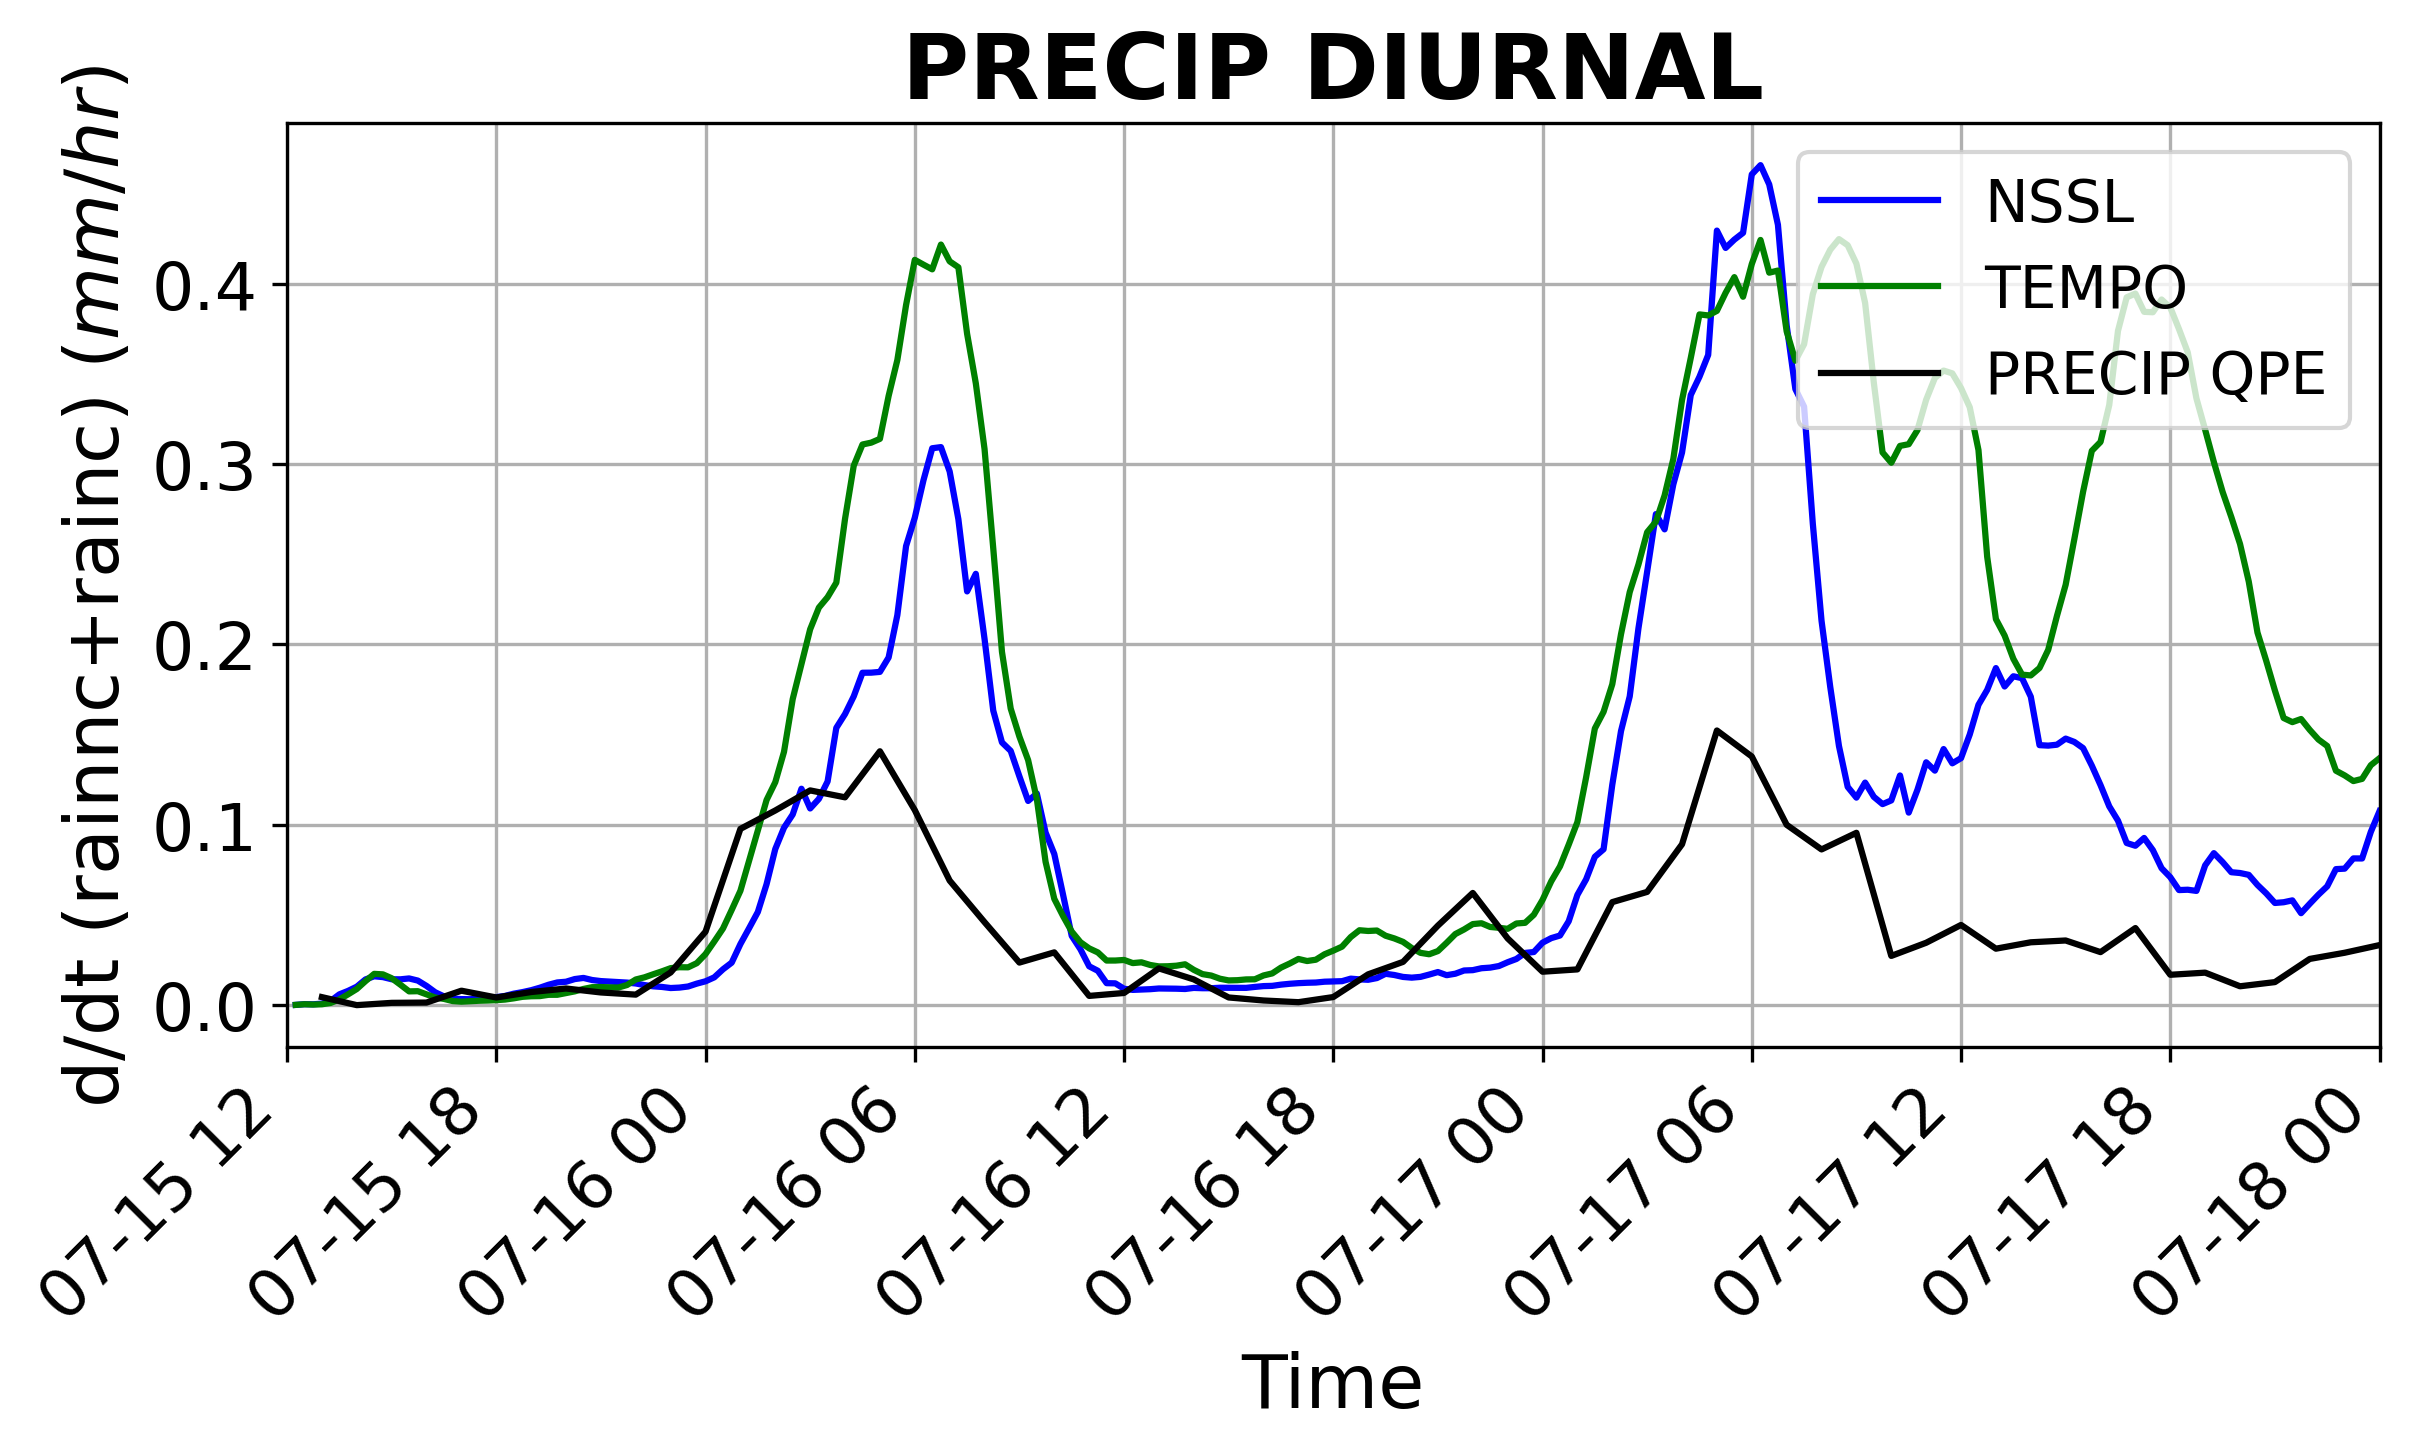

In [183]:
fig =  MakeCombinedPlot_2()
SaveFigure(fig,ModelData_NSSL,ModelData_TEMPO,
           plotType="RainRate")
fig